In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('co2.csv')


In [2]:
print(df.select_dtypes(include='number').columns)

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='str')


In [3]:
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)']

target = ['CO2 Emissions(g/km)']

In [4]:
x = df[features].values
y = df[target].values.flatten()

In [5]:
np.random.seed(33)

indices = np.random.permutation(len(x))

split = int(0.8*len(x))

train_split = indices[:split]
test_split = indices[split:]

x_train = x[train_split]
x_test = x[test_split]

y_train = y[train_split]
y_test = y[test_split]

In [6]:
mean = np.mean(x_train, axis = 0)
std = np.std(x_train, axis = 0)
x_train = (x_train - mean)/std
x_test = (x_test - mean)/std

In [7]:
weights = np.zeros(x.shape[1])
bias = 0
learning_rate = 0.1

In [8]:
for i in range(10000):
    y_pred = bias + x_train@weights
    error = y_pred - y_train
    dw = (1/len(x_train))*(x_train.T@error)
    db = (1/len(x_train))*np.sum(error)
    weights = weights - learning_rate * dw    
    bias = bias - (learning_rate*db)


In [9]:
y_pred_test = bias + x_test@weights
print(y_pred_test[:10])


[310.34916226 299.12742476 220.50156006 266.67297755 279.21202851
 376.36717468 189.10629742 261.00343129 294.83254247 299.09605422]


In [10]:
ss_tot = np.sum((y_test - np.mean(y_pred_test))**2)
ss_res = np.sum((y_test - y_pred_test)**2)
r2 = 1 - (ss_res/ss_tot)
print(f"R2: {r2}")


R2: 0.8715252620606765


In [11]:
mae = np.mean(np.abs(y_test - y_pred_test))
print("MAE:", mae)

MAE: 13.987272936304604


In [12]:
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

accuracy = 100 - mape

print("Accuracy:", accuracy, "%")

Accuracy: 94.3052051014976 %


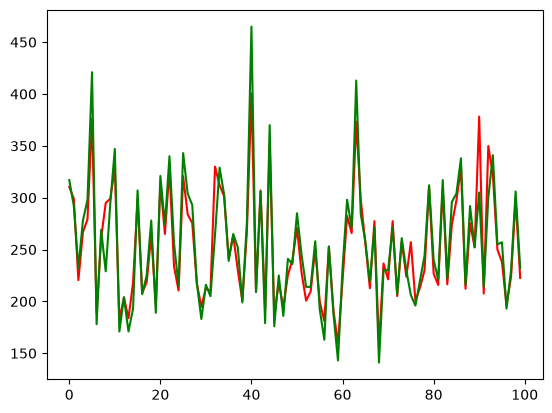

In [13]:
import matplotlib.pylab as plt

plt.plot(y_pred_test[:100], color = 'red')
plt.plot(y_test[:100], color='green')
plt.show()